# 05. Compare mutational spectra

This notebook builds DB-weighted mutational spectra for groups prepared in `03_prepare_spectrum_groups.ipynb` and weighted in `04_add_spectrum_weights.ipynb`.

The input table is:

```text
../results/spectrum_groups/spectrum_groups_with_weights_T95.tsv
```

The key weight is:

```text
combined_db_spectrum_weight
```

It is calculated in the previous step as:

```text
combined_db_spectrum_weight =
    max(gnomAD_count + Helix_count, 1)
    /
    ((gnomAD_total + Helix_total) × ref_base_count)
```

Before the opportunity counts are used here, all positions belonging to canonical MITOMAP loci marked `[on complement]` are reverse-complemented into their functional-strand orientation. Here `ref_base_count` is therefore recomputed as the number of strand-oriented reference nucleotides of the same type as the mutated base. For example, `A>G` is normalized by the number of oriented `A` nucleotides, and `C>T` by the number of oriented `C` nucleotides. Original rCRS-oriented columns are retained with an `_rcrs` suffix for QC.

The strand-oriented weights are calculated once before spectrum aggregation. We then sum them by group and substitution type and divide all groups by one shared total weight.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [2]:
# ============================================================
# Paths
# ============================================================

INPUT_PATH = Path("../results/spectrum_groups/spectrum_groups_with_weights_T95.tsv")
MITOMAP_LOCI_INPUT = Path("../data/raw/mitomap/mitomap_genome_loci_192_r889.tsv")

OUTPUT_DIR = Path("../results/mutation_spectra")
FIGURE_DIR = Path("../results/figures/mutation_spectra_T95")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPECTRUM_OUTPUT = OUTPUT_DIR / "spectrum_weighted_frequencies_T95.tsv"

WEIGHT_COL = "combined_db_spectrum_weight"
GROUP_COL = "spectrum_group_primary_T95"
EXPECTED_COMPLEMENT_LOCI = {
    "MT-ND6", "MT-TQ", "MT-TA", "MT-TN", "MT-TC",
    "MT-TY", "MT-TS1", "MT-TE", "MT-TP",
}
DNA_COMPLEMENT = {"A": "T", "C": "G", "G": "C", "T": "A"}

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]

## Load spectrum-group table

At this stage each row is one possible mtDNA SNV. The table contains the group assignment from Isolation Forest and rCRS-oriented population counts from gnomAD + Helix. This notebook assigns canonical complement-strand positions from MITOMAP, reverse-complements their alleles, and recomputes opportunity-normalized weights before any aggregation or plotting.

In [3]:
df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)
loci = pd.read_csv(MITOMAP_LOCI_INPUT, sep="\t")

required_cols = {
    "variant_id", "position", "reference", "alternate",
    "substitution_type_12", "is_valid_snv_substitution",
    "combined_db_count_raw", "combined_db_count_pc",
    "combined_db_total_records", "ref_base_count",
    "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw", GROUP_COL,
}
missing_cols = sorted(required_cols.difference(df.columns))
if missing_cols:
    raise ValueError(f"Missing required 12-spectrum columns: {missing_cols}")

complement_loci = loci[loci["map_locus"].isin(EXPECTED_COMPLEMENT_LOCI)].copy()
observed_complement_loci = set(
    complement_loci.loc[
        complement_loci["description"].str.contains(
            "[on complement]", regex=False, na=False
        ),
        "map_locus",
    ]
)
if observed_complement_loci != EXPECTED_COMPLEMENT_LOCI:
    raise ValueError(
        f"Unexpected complement-strand loci: {sorted(observed_complement_loci)}"
    )

def expand_circular_interval(start, end, genome_length=16569):
    start = int(start)
    end = int(end)
    if start <= end:
        return range(start, end + 1)
    return list(range(start, genome_length + 1)) + list(range(1, end + 1))


complement_positions = set()
for row in complement_loci.itertuples(index=False):
    complement_positions.update(expand_circular_interval(row.start, row.end))

work = df[df["is_valid_snv_substitution"] == 1].copy()
rcrs_cols = [
    "reference", "alternate", "substitution_type_12",
    "ref_base_count", "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw",
]
for column in rcrs_cols:
    work[f"{column}_rcrs"] = work[column]

work["is_complement_strand"] = work["position"].isin(complement_positions)
complement_mask = work["is_complement_strand"]
work.loc[complement_mask, "reference"] = (
    work.loc[complement_mask, "reference_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "alternate"] = (
    work.loc[complement_mask, "alternate_rcrs"].map(DNA_COMPLEMENT)
)
work["substitution_type_12"] = work["reference"] + ">" + work["alternate"]

position_universe = (
    work[["position", "reference", "is_complement_strand"]]
    .drop_duplicates("position")
)
if len(position_universe) * 3 != len(work):
    raise ValueError("Expected exactly three alternate SNVs per position.")
ref_base_counts = position_universe["reference"].value_counts()
work["ref_base_count"] = work["reference"].map(ref_base_counts)

rcrs_position_universe = (
    work[["position", "reference_rcrs"]].drop_duplicates("position")
)
rcrs_base_counts = rcrs_position_universe["reference_rcrs"].value_counts()
if not np.array_equal(
    work["ref_base_count_rcrs"].to_numpy(),
    work["reference_rcrs"].map(rcrs_base_counts).to_numpy(),
):
    raise ValueError("rCRS base opportunities no longer match notebook 04.")

db_total = pd.to_numeric(work["combined_db_total_records"], errors="raise")
if db_total.nunique() != 1 or (db_total <= 0).any():
    raise ValueError("Expected one positive combined database denominator.")
work[WEIGHT_COL] = (
    work["combined_db_count_pc"] / (db_total * work["ref_base_count"])
)
work["combined_db_spectrum_weight_raw"] = (
    work["combined_db_count_raw"] / (db_total * work["ref_base_count"])
)

if int(position_universe["is_complement_strand"].sum()) != len(complement_positions):
    raise ValueError("Not every complement-strand position was oriented.")
if not work.loc[~complement_mask, "substitution_type_12"].equals(
    work.loc[~complement_mask, "substitution_type_12_rcrs"]
):
    raise ValueError("Reference-strand substitutions changed unexpectedly.")
nd6_example = work[
    (work["position"] == 14149) & (work["alternate_rcrs"] == "A")
]
if nd6_example["substitution_type_12"].tolist() != ["G>T"]:
    raise ValueError("m.14149C>A was not oriented to G>T.")

work = work[work[GROUP_COL] != "exclude"].copy()

print("Input shape:", df.shape)
print("Analysis table shape:", work.shape)
print("Complement-strand loci:", sorted(observed_complement_loci))
print("Reverse-complemented positions:", len(complement_positions))
print("Strand-oriented base opportunities:", ref_base_counts.to_dict())

print("\nGroups:")
print(work[GROUP_COL].value_counts(dropna=False))

print("\nWeight summary:")
print(work[WEIGHT_COL].describe())

Input shape: (49704, 56)
Analysis table shape: (49564, 63)
Complement-strand loci: ['MT-ND6', 'MT-TA', 'MT-TC', 'MT-TE', 'MT-TN', 'MT-TP', 'MT-TQ', 'MT-TS1', 'MT-TY']
Reverse-complemented positions: 1076
Strand-oriented base opportunities: {'A': 4979, 'C': 4952, 'T': 4239, 'G': 2398}

Groups:
spectrum_group_primary_T95
unlabeled_out_of_neutral_domain_T95    27649
expanded_neutral_like_T95              21915
Name: count, dtype: int64

Weight summary:
count    4.956400e+04
mean     1.351936e-07
std      3.092267e-06
min      7.956815e-10
25%      8.000199e-10
50%      9.345832e-10
75%      1.652084e-09
max      2.568446e-04
Name: combined_db_spectrum_weight, dtype: float64


## Calculate weighted mutational spectrum

For each group `g` and substitution type `t`:

```text
weighted_sum(g, t) =
    Σ combined_db_spectrum_weight_i
```

where the sum is taken over all variants `i` that belong to group `g` and substitution type `t`.

Then we normalize the weights across all analyzed groups using one shared denominator:

```text
weighted_frequency(g, t) =
    weighted_sum(g, t) / Σ weighted_sum(all groups, all substitution types)
```

This keeps both groups on one scale: the 24 frequencies jointly sum to one, while each group's sum retains its share of the total spectrum weight.

In [4]:
def compute_weighted_spectrum(data, group_col, weight_col):
    spectrum = (
        data
        .groupby([group_col, "substitution_type_12"], as_index=False)
        .agg(
            n_variants=("variant_id", "count"),
            weighted_sum=(weight_col, "sum"),
        )
        .rename(columns={
            group_col: "group_name",
            "substitution_type_12": "substitution_type",
        })
    )

    all_groups = sorted(spectrum["group_name"].dropna().unique())

    complete_index = pd.MultiIndex.from_product(
        [all_groups, substitution_order_12],
        names=["group_name", "substitution_type"],
    )

    spectrum = (
        spectrum
        .set_index(["group_name", "substitution_type"])
        .reindex(complete_index)
        .reset_index()
    )

    spectrum["n_variants"] = spectrum["n_variants"].fillna(0).astype(int)
    spectrum["weighted_sum"] = spectrum["weighted_sum"].fillna(0.0)

    spectrum["total_weight"] = spectrum["weighted_sum"].sum()
    if spectrum["total_weight"].iloc[0] <= 0:
        raise ValueError("The shared spectrum total must be positive.")

    spectrum["weighted_frequency"] = (
        spectrum["weighted_sum"] / spectrum["total_weight"]
    )

    spectrum.insert(0, "group_col", group_col)
    spectrum["weight_col"] = weight_col

    return spectrum


spectrum = compute_weighted_spectrum(
    data=work,
    group_col=GROUP_COL,
    weight_col=WEIGHT_COL,
)

assert spectrum.groupby("group_name").size().eq(12).all()
assert np.isclose(spectrum["weighted_frequency"].sum(), 1.0)

spectrum.to_csv(SPECTRUM_OUTPUT, sep="\t", index=False)

print("Saved:", SPECTRUM_OUTPUT)
display(spectrum.head(24))

Saved: ..\results\mutation_spectra\spectrum_weighted_frequencies_T95.tsv


,group_col,group_name,substitution_type,n_variants,weighted_sum,total_weight,weighted_frequency,weight_col
0,spectrum_group_primary_T95,expanded_neutral_like_T95,A>C,2230,0.000020,0.006701,0.002950,combined_db_spectrum_weight
1,spectrum_group_primary_T95,expanded_neutral_like_T95,A>G,2902,0.001358,0.006701,0.202629,combined_db_spectrum_weight
2,spectrum_group_primary_T95,expanded_neutral_like_T95,A>T,2272,0.000019,0.006701,0.002788,combined_db_spectrum_weight
3,spectrum_group_primary_T95,expanded_neutral_like_T95,C>A,2460,0.000066,0.006701,0.009869,combined_db_spectrum_weight
4,spectrum_group_primary_T95,expanded_neutral_like_T95,C>G,2406,0.000005,0.006701,0.000778,combined_db_spectrum_weight
5,spectrum_group_primary_T95,expanded_neutral_like_T95,C>T,3091,0.000759,0.006701,0.113247,combined_db_spectrum_weight
6,spectrum_group_primary_T95,expanded_neutral_like_T95,G>A,909,0.001900,0.006701,0.283554,combined_db_spectrum_weight
7,spectrum_group_primary_T95,expanded_neutral_like_T95,G>C,660,0.000024,0.006701,0.003635,combined_db_spectrum_weight
8,spectrum_group_primary_T95,expanded_neutral_like_T95,G>T,640,0.000010,0.006701,0.001441,combined_db_spectrum_weight
9,spectrum_group_primary_T95,expanded_neutral_like_T95,T>A,1274,0.000015,0.006701,0.002231,combined_db_spectrum_weight


## Plot functions

The plots below use `weighted_frequency` as the spectrum value. This is the final DB-weighted spectrum.

In [5]:
group_label_map = {
    "expanded_neutral_like_T95": "Expanded neutral-like",
    "strict_expanded_neutral_like_T95": "Strict expanded neutral-like",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain",
    "known_neutral_reference": "Known neutral reference",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
    "unlabeled_neutral_like_T95": "Unlabeled neutral-like",
}


def safe_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(">", "to")
        .replace(":", "_")
    )


def plot_single_spectrum(spectrum_df, group_name, output_dir=FIGURE_DIR):
    plot_df = (
        spectrum_df[spectrum_df["group_name"] == group_name]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    x = np.arange(len(substitution_order_12))
    y = plot_df["weighted_frequency"].values

    label = group_label_map.get(group_name, group_name)
    n_variants = int(plot_df["n_variants"].sum())

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented substitution type")
    plt.title(f"{label} n={n_variants}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_{safe_filename(group_name)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_two_group_comparison(spectrum_df, group_1, group_2, output_dir=FIGURE_DIR):
    df1 = (
        spectrum_df[spectrum_df["group_name"] == group_1]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    df2 = (
        spectrum_df[spectrum_df["group_name"] == group_2]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    x = np.arange(len(substitution_order_12))
    width = 0.4

    label_1 = group_label_map.get(group_1, group_1)
    label_2 = group_label_map.get(group_2, group_2)

    plt.figure(figsize=(11, 5))
    plt.bar(x - width / 2, df1["weighted_frequency"].values, width=width, label=label_1)
    plt.bar(x + width / 2, df2["weighted_frequency"].values, width=width, label=label_2)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented substitution type")
    plt.title("DB-weighted mutational spectrum comparison (shared denominator)")
    plt.legend()
    plt.tight_layout()

    output_path = output_dir / f"spectrum_comparison_{safe_filename(group_1)}_vs_{safe_filename(group_2)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_spectrum_difference(spectrum_df, reference_group, comparison_group, output_dir=FIGURE_DIR):
    ref = (
        spectrum_df[spectrum_df["group_name"] == reference_group]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    comp = (
        spectrum_df[spectrum_df["group_name"] == comparison_group]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    diff = comp["weighted_frequency"].values - ref["weighted_frequency"].values

    x = np.arange(len(substitution_order_12))

    label_ref = group_label_map.get(reference_group, reference_group)
    label_comp = group_label_map.get(comparison_group, comparison_group)

    plt.figure(figsize=(10, 5))
    plt.bar(x, diff)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Difference in shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented substitution type")
    plt.title(f"{label_comp} minus {label_ref}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_difference_{safe_filename(comparison_group)}_minus_{safe_filename(reference_group)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

## Main plots

The main comparison is between the expanded neutral-like group and variants outside the neutral domain.

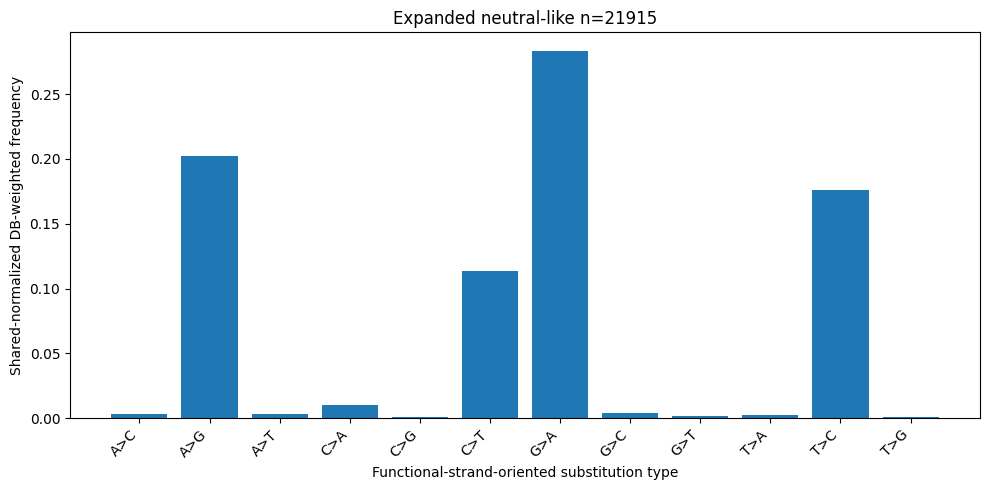

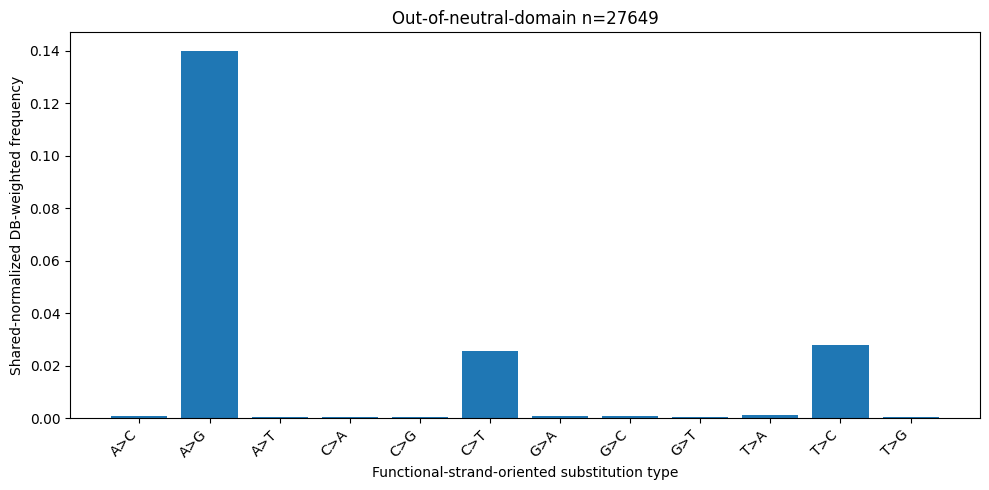

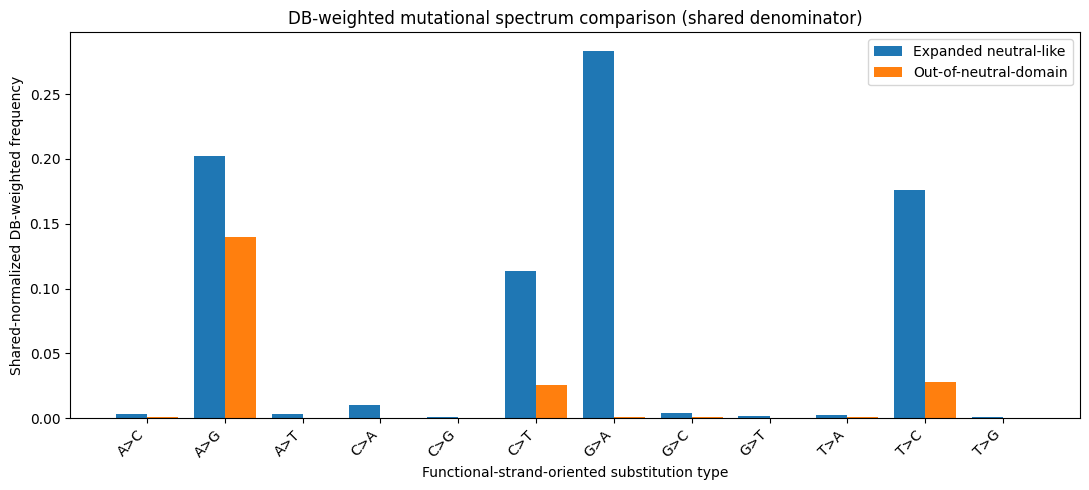

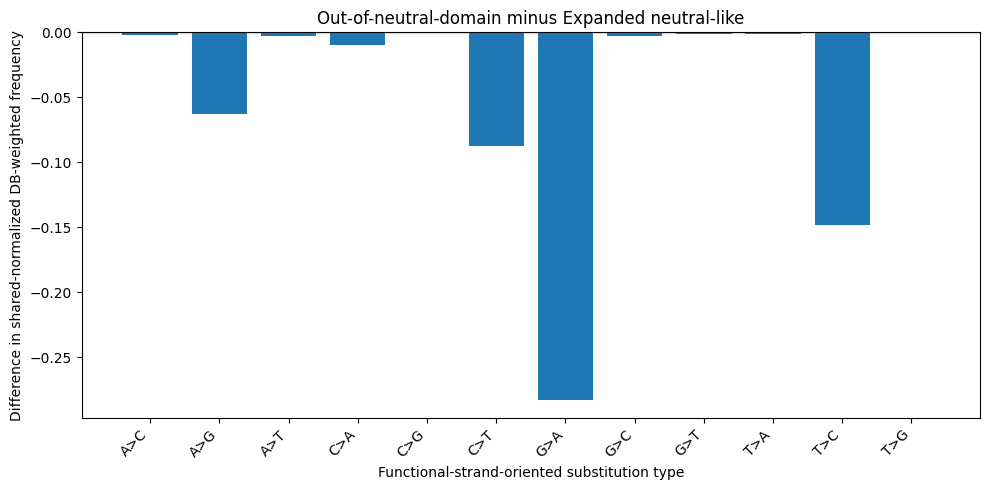

Figures saved to: ..\results\figures\mutation_spectra_T95


In [6]:
neutral_like_group = "expanded_neutral_like_T95"
out_of_domain_group = "unlabeled_out_of_neutral_domain_T95"

plot_single_spectrum(spectrum, neutral_like_group)
plot_single_spectrum(spectrum, out_of_domain_group)

plot_two_group_comparison(
    spectrum,
    group_1=neutral_like_group,
    group_2=out_of_domain_group,
)

plot_spectrum_difference(
    spectrum,
    reference_group=neutral_like_group,
    comparison_group=out_of_domain_group,
)

print("Figures saved to:", FIGURE_DIR)